# Goal Kick OBV Model — Standardized Features

Same 80/20 temporal split approach as `goal_kick_model.ipynb`, but features are
scaled with `StandardScaler` (zero mean, unit variance) before training.

This makes Ridge coefficients directly comparable across features,
giving a true picture of which features matter most.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pickle

PROJECT_ROOT = Path('../')
model_df = pd.read_parquet(PROJECT_ROOT / 'data' / 'feature_engineering' / 'model_features_80_20.parquet')
print(f'Loaded : {model_df.shape}')

Loaded : (5113, 22)


## Encode + clean

In [2]:
le = LabelEncoder()
model_df['action_type_enc'] = le.fit_transform(model_df['action_type'].fillna('Unknown'))

FEATURE_COLS = [
    'obv_for_80', 'obv_against_80',
    'n_prog_passes_80', 'n_prog_carries_80', 'final_third_80',
    'press_compactness_80', 'press_height_mean_x_80', 'press_height_max_x_80',
    'def_line_depth_mean_x_80', 'avg_def_ball_dist_80', 'min_def_ball_dist_80',
    'n_frames_pressure_80', 'press_fwd_speed_80',
    'action_type_enc', 'action_x', 'action_y', 'action_progressive',
    'period',
]
TARGET_COL = 'obv_remaining'

df_clean = model_df[FEATURE_COLS + [TARGET_COL]].dropna()
X = df_clean[FEATURE_COLS].values
y = df_clean[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train : {len(X_train):,}  |  Test : {len(X_test):,}')

Train : 4,068  |  Test : 1,018


## Standardize features

Scaler is fit **only on the training set** to avoid data leakage, then applied to both train and test.

In [3]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only
X_test_s  = scaler.transform(X_test)         # apply same scale to test
X_all_s   = scaler.transform(X)              # for cross-validation

print('Feature means (should be ~0 after scaling):')
print(pd.Series(X_train_s.mean(axis=0), index=FEATURE_COLS).round(4).to_string())
print()
print('Feature stds (should be ~1 after scaling):')
print(pd.Series(X_train_s.std(axis=0), index=FEATURE_COLS).round(4).to_string())

Feature means (should be ~0 after scaling):
obv_for_80                 -0.0
obv_against_80             -0.0
n_prog_passes_80            0.0
n_prog_carries_80          -0.0
final_third_80             -0.0
press_compactness_80       -0.0
press_height_mean_x_80     -0.0
press_height_max_x_80       0.0
def_line_depth_mean_x_80   -0.0
avg_def_ball_dist_80        0.0
min_def_ball_dist_80       -0.0
n_frames_pressure_80        0.0
press_fwd_speed_80          0.0
action_type_enc             0.0
action_x                   -0.0
action_y                    0.0
action_progressive          0.0
period                      0.0

Feature stds (should be ~1 after scaling):
obv_for_80                  1.0
obv_against_80              1.0
n_prog_passes_80            1.0
n_prog_carries_80           1.0
final_third_80              1.0
press_compactness_80        1.0
press_height_mean_x_80      1.0
press_height_max_x_80       1.0
def_line_depth_mean_x_80    1.0
avg_def_ball_dist_80        1.0
min_def_ball_dis

## Train models on standardized features

In [4]:
models = {
    'Ridge Regression'  : Ridge(alpha=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, max_depth=6,
                                                 min_samples_leaf=10, random_state=42, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                     learning_rate=0.05, min_samples_leaf=10,
                                                     random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    rmse   = np.sqrt(mean_squared_error(y_test, y_pred))
    mae    = mean_absolute_error(y_test, y_pred)
    r2     = r2_score(y_test, y_pred)
    cv_r2  = cross_val_score(model, X_all_s, y, cv=5, scoring='r2').mean()
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'CV_R2': cv_r2}
    print(f'{name:<25}  RMSE={rmse:.4f}  MAE={mae:.4f}  R2={r2:.4f}  CV_R2={cv_r2:.4f}')

best_name  = max(results, key=lambda k: results[k]['R2'])
best_model = models[best_name]
print(f'\nBest model: {best_name}')

Ridge Regression           RMSE=0.0651  MAE=0.0172  R2=0.1771  CV_R2=0.0347


Random Forest              RMSE=0.0690  MAE=0.0166  R2=0.0762  CV_R2=0.0192


Gradient Boosting          RMSE=0.0684  MAE=0.0178  R2=0.0911  CV_R2=0.0168

Best model: Ridge Regression


## Feature importance (standardized coefficients)

With standardized features, all coefficients are on the same scale.
A larger absolute coefficient means the feature genuinely moves the prediction more.

Standardized Ridge coefficients (comparable importance):
obv_for_80                  0.011836
def_line_depth_mean_x_80    0.008611
press_height_mean_x_80     -0.007142
obv_against_80             -0.005673
n_prog_passes_80            0.004240
action_type_enc            -0.003190
n_frames_pressure_80       -0.002293
min_def_ball_dist_80        0.002085
final_third_80             -0.001968
avg_def_ball_dist_80       -0.001892
action_y                    0.001652
action_progressive          0.001291
press_compactness_80        0.001270
n_prog_carries_80          -0.001199
action_x                   -0.000514
press_fwd_speed_80         -0.000426
period                     -0.000169
press_height_max_x_80      -0.000119


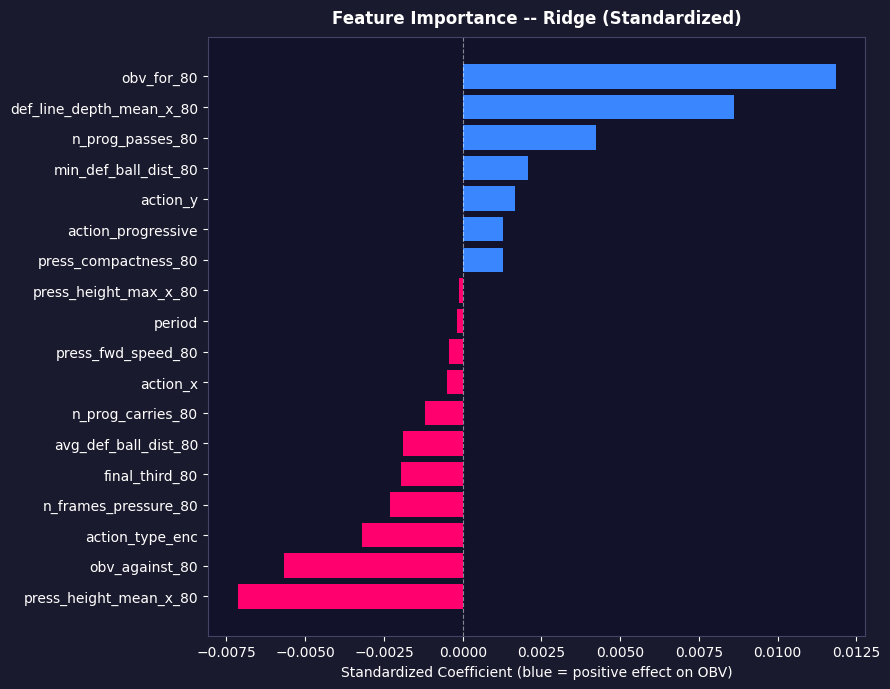

In [5]:
ridge = models['Ridge Regression']
coefs = pd.Series(ridge.coef_, index=FEATURE_COLS).sort_values(key=abs, ascending=False)

print('Standardized Ridge coefficients (comparable importance):')
print(coefs.round(6).to_string())

fig, ax = plt.subplots(figsize=(9, 7), facecolor='#1a1a2e')
ax.set_facecolor('#12122a')
sorted_coefs = coefs.sort_values()
colors = ['#3a86ff' if v > 0 else '#ff006e' for v in sorted_coefs.values]
ax.barh(sorted_coefs.index, sorted_coefs.values, color=colors)
ax.axvline(0, color='white', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Standardized Coefficient (blue = positive effect on OBV)', color='white')
ax.set_title('Feature Importance -- Ridge (Standardized)', color='white',
             fontweight='bold', pad=10)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('#444466')
plt.tight_layout()
plt.savefig('../model/feature_importance_standardized.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## Actual vs Predicted

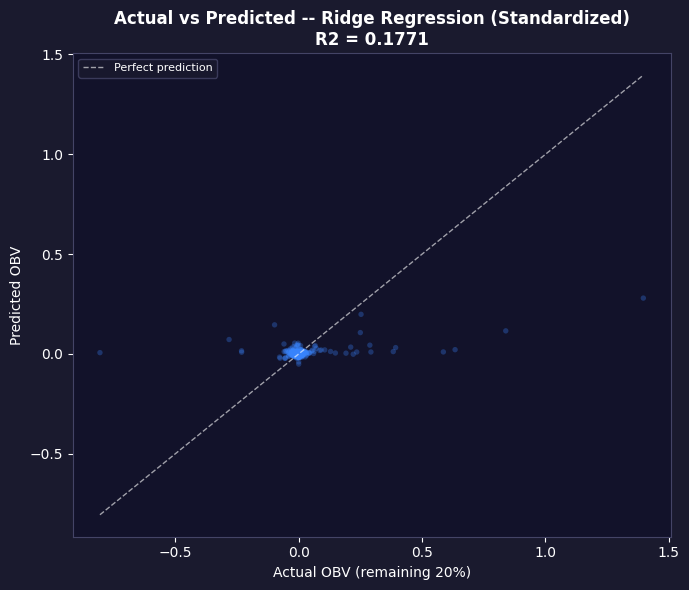

In [6]:
y_pred_test = best_model.predict(X_test_s)

fig, ax = plt.subplots(figsize=(7, 6), facecolor='#1a1a2e')
ax.set_facecolor('#12122a')
ax.scatter(y_test, y_pred_test, alpha=0.3, s=15, color='#3a86ff', edgecolors='none')
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax.plot(lims, lims, 'w--', linewidth=1, alpha=0.6, label='Perfect prediction')
ax.set_xlabel('Actual OBV (remaining 20%)', color='white')
ax.set_ylabel('Predicted OBV', color='white')
ax.set_title(f'Actual vs Predicted -- {best_name} (Standardized)\nR2 = {results[best_name]["R2"]:.4f}',
             color='white', fontweight='bold')
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1a2e', labelcolor='white', edgecolor='#444466', fontsize=8)
for spine in ax.spines.values():
    spine.set_color('#444466')
plt.tight_layout()
plt.savefig('../model/actual_vs_predicted_standardized.png', dpi=150,
            bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## Save standardized model

In [7]:
with open('../model/best_model_standardized.pkl', 'wb') as f:
    pickle.dump({
        'model'        : best_model,
        'scaler'       : scaler,
        'label_encoder': le,
        'feature_cols' : FEATURE_COLS,
        'model_name'   : best_name,
        'results'      : results,
    }, f)

print(f'Saved -> model/best_model_standardized.pkl  ({best_name})')
print()
print('Final metrics:')
for metric, val in results[best_name].items():
    print(f'  {metric:<10}: {val:.4f}')

Saved -> model/best_model_standardized.pkl  (Ridge Regression)

Final metrics:
  RMSE      : 0.0651
  MAE       : 0.0172
  R2        : 0.1771
  CV_R2     : 0.0347
